<a href="https://colab.research.google.com/github/Vythursh1998/Data-Science-Big-Data-Analytics/blob/main/DataScienceTelco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GSCOMP259_CSC 630_Data Science, Business Intelligence and Big Data Analysis

# Data Science & Big Data Analytics: Telecommunications Customer Churn Prediction
**A Localized Analysis of the Sri Lankan Telecommunications Market**

**Objective:** This notebook demonstrates a complete, end-to-end data analytics and machine learning lifecycle. Utilizing the IBM Telco Customer Churn dataset, the data is engineered and localized to simulate the Sri Lankan telecommunications market. The analysis covers descriptive exploration, diagnostic statistical testing, predictive modeling, and prescriptive business optimization.

**File adding methods**

Method 1: Mount Google Drive. To link the document through the drive. This contains the file always here.

In [ ]:
#link the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#unmount from drive
from google.colab import drive
drive.flush_and_unmount()
print("Drive unmounted successfully.")

Drive unmounted successfully.


Method 2: Direct Upload. This is the fastest method, but the file will be deleted when Colab session disconnects. Should upload it again if the tab closes.


*   Option 1: Using the Menu (No extra code needed)
*    Option 2: Using Python Code (It will prompt to choose a file from computer:)




**Actual Starting point.....................**

In [ ]:
from google.colab import files
import pandas as pd

# This will open an upload button below the cell
uploaded = files.upload()

# Get the name of the uploaded file
uploaded_file_name = list(uploaded.keys())[0]

# Once uploaded, read the file
df = pd.read_csv(uploaded_file_name)
df.head()

Saving telco_customer_churn.csv to telco_customer_churn (1).csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Phase 1: Environment Setup and Data Ingestion
In this initial phase, we establish our robust analytical environment by importing industry-standard libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`).

We also initialize the `shap` library for advanced Explainable AI (XAI) later in the pipeline. After setting up the environment, we load the raw dataset to inspect its initial shape and data types.

In [30]:
!pip install shap -q

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import shap



In [36]:
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("matplotlib", plt.matplotlib.__version__)
print("seaborn", sns.__version__)
print("shap", shap.__version__)

pandas 2.2.2
numpy 2.0.2
matplotlib 3.10.0
seaborn 0.13.2
shap 0.52.0


In [37]:
# Load the Kaggle dataset
df = pd.read_csv('telco_customer_churn.csv')

# Display initial characteristics
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Phase 2: Feature Engineering & Sri Lankan Localization (Data Preprocessing)
Raw data rarely arrives ready for machine learning. In this phase, we address data quality issues and perform feature engineering to map the dataset to a local Sri Lankan business context.

**Key Operations:**
1. **Missing Data Imputation:** Visualizing and fixing hidden missing values in the `TotalCharges` column using median imputation to maintain data integrity.
2. **Financial Localization:** Converting standard USD financial metrics to Sri Lankan Rupees (LKR).
3. **Service Localization:** Renaming generic ISP terminology to reflect local market competitors (e.g., SLT-Mobitel Fibre and Dialog 4G Home Broadband).



--- Missing Data Check ---


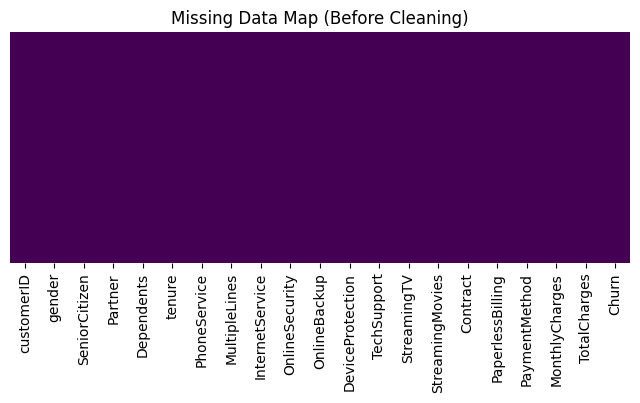

In [38]:
print("--- Missing Data Check ---")
plt.figure(figsize=(8, 3))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Map (Before Cleaning)")
plt.show()

In [39]:
# 1. Fix hidden missing values in TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 2. Localize Currency (USD to LKR)
exchange_rate = 300
df['MonthlyCharges_LKR'] = df['MonthlyCharges'] * exchange_rate
df['TotalCharges_LKR'] = df['TotalCharges'] * exchange_rate

# Drop old USD columns
df = df.drop(columns=['MonthlyCharges', 'TotalCharges'])

# 3. Localize Services to mimic the Sri Lankan market
df['InternetService'] = df['InternetService'].replace({
    'Fiber optic': 'SLT-Mobitel Fibre',
    'DSL': 'Dialog 4G Home Broadband'
})

# 4. Drop useless identifiers
df = df.drop(columns=['customerID'])

## Phase 3: Exploratory & Diagnostic Data Analysis (EDA)
This phase fulfills the **Descriptive** and **Diagnostic** requirements of the analytics lifecycle. We utilize statistical summaries and visualizations to understand the underlying distributions and identify the primary drivers of customer churn.

**Analytical Steps:**
* **Univariate Analysis:** Inspecting value counts and utilizing `pd.qcut` for quantile binning (discretizing continuous variables like tenure).
* **Outlier Detection:** Implementing boxplots to identify anomalies in financial distributions.
* **Bivariate Analysis & Visualization:** Utilizing custom subplots and pie charts to visualize the relationship between contract types and churn rates.
* **Statistical Dependency Testing:** Executing a Chi-Square test to mathematically prove the dependency between categorical variables, alongside a correlation matrix for numerical features.





In [41]:
print("\n--- Basic Inspection & Value Counts ---")
print(f"Dataset Shape: {df.shape}")
print(f"Unique Internet Services: {df['InternetService'].unique()}")
print("\nInternet Service Value Counts:")
print(df['InternetService'].value_counts())


--- Basic Inspection & Value Counts ---
Dataset Shape: (7043, 20)
Unique Internet Services: ['Dialog 4G Home Broadband' 'SLT-Mobitel Fibre' 'No']

Internet Service Value Counts:
InternetService
SLT-Mobitel Fibre           3096
Dialog 4G Home Broadband    2421
No                          1526
Name: count, dtype: int64


In [43]:
print("\n--- Quantile Binning (pd.qcut) ---")
df['Tenure_Quartile'] = pd.qcut(df['tenure'], q=4, labels=['New', 'Mid-Term', 'Long-Term', 'Loyal'])
print(df['Tenure_Quartile'].value_counts().sort_index())
df = df.drop(columns=['Tenure_Quartile']) # Drop after exploring so it doesn't break the ML model


--- Quantile Binning (pd.qcut) ---
Tenure_Quartile
New          1854
Mid-Term     1715
Long-Term    1719
Loyal        1755
Name: count, dtype: int64


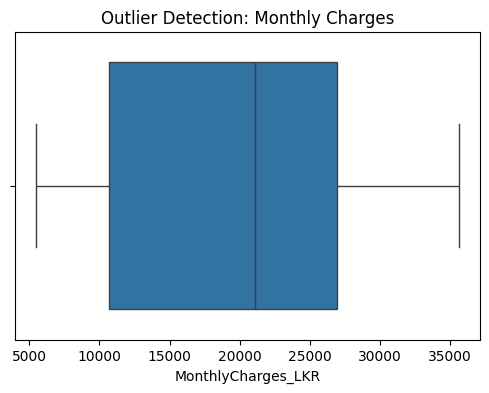

In [45]:
# Outlier Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['MonthlyCharges_LKR'])
plt.title('Outlier Detection: Monthly Charges')
plt.show()


--- Subplots & Customized Pie Chart ---


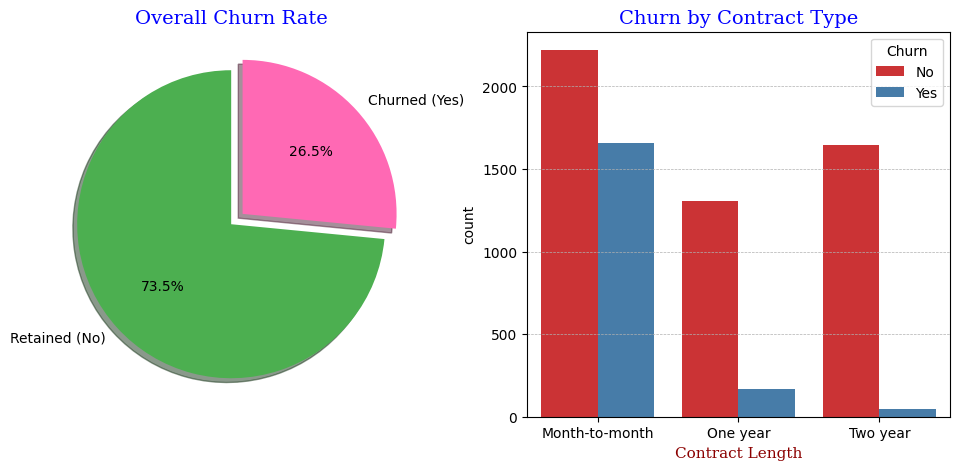

In [51]:
print("\n--- Subplots & Customized Pie Chart ---")
font1 = {'family':'serif','color':'blue','size':14}
font2 = {'family':'serif','color':'darkred','size':11}

plt.figure(figsize=(12, 5))
# Plot 1: Pie Chart
plt.subplot(1, 2, 1)
y_pie = df['Churn'].value_counts().values
plt.pie(y_pie, labels=["Retained (No)", "Churned (Yes)"], startangle=90,
        explode=[0, 0.1], colors=["#4CAF50", "hotpink"], shadow=True, autopct='%1.1f%%')
plt.title("Overall Churn Rate", fontdict=font1)

# Plot 2: Countplot
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title("Churn by Contract Type", fontdict=font1)
plt.xlabel("Contract Length", fontdict=font2)
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.show()

/tmp/ipykernel_1941/2593543024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


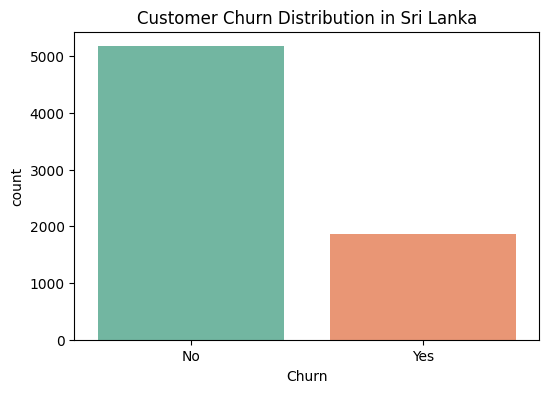

In [52]:
# Visualize Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Customer Churn Distribution in Sri Lanka')
plt.show()



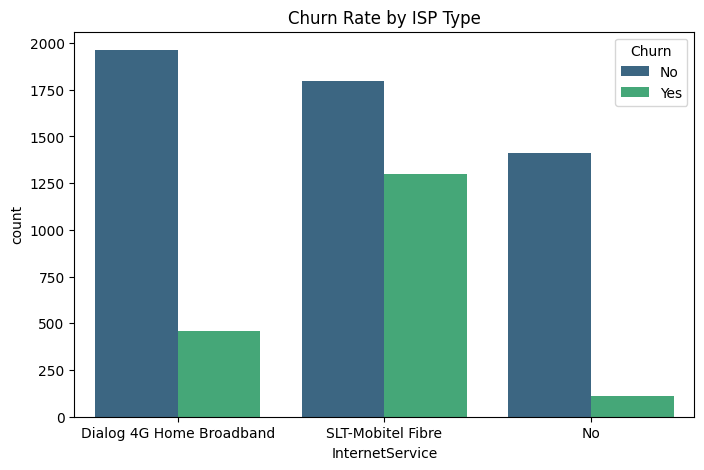

In [53]:
# Analyze Churn by Internet Service Type
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='viridis')
plt.title('Churn Rate by ISP Type')
plt.show()

In [54]:
# 1. Show Min, Max, and standard stats for numerical data
print("--- Basic Statistics ---")
print(df.describe())

--- Basic Statistics ---
       SeniorCitizen       tenure  MonthlyCharges_LKR  TotalCharges_LKR
count    7043.000000  7043.000000         7043.000000      7.043000e+03
mean        0.162147    32.371149        19428.507738      6.845751e+05
std         0.368612    24.559481         9027.014129      6.795811e+05
min         0.000000     0.000000         5475.000000      5.640000e+03
25%         0.000000     9.000000        10650.000000      1.206675e+05
50%         0.000000    29.000000        21105.000000      4.192425e+05
75%         0.000000    55.000000        26955.000000      1.135980e+06
max         1.000000    72.000000        35625.000000      2.605440e+06


In [55]:
# Chi-Square Dependency Test (Categorical vs Categorical Dependency)
# Testing if 'Contract' type depends on 'Churn'

print("\n--- Chi-Square & Correlation (Diagnostic) ---")
contingency = pd.crosstab(df['Contract'], df['Churn'])
chi2, p, _, _ = chi2_contingency(contingency)


print(f"\nChi-Square Test (Contract vs Churn)")
print(f"Chi-Square value: {chi2}")
print(f"P-value: {p}")
print("Note: If p-value < 0.05, it proves the variables are highly dependent!")


--- Chi-Square & Correlation (Diagnostic) ---

Chi-Square Test (Contract vs Churn)
Chi-Square value: 1184.5965720837926
P-value: 5.863038300673391e-258
Note: If p-value < 0.05, it proves the variables are highly dependent!


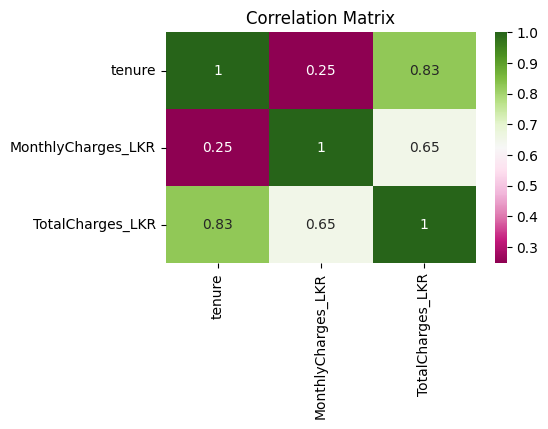

In [56]:
tc = df[['tenure', 'MonthlyCharges_LKR', 'TotalCharges_LKR']].corr()
plt.figure(figsize=(5, 3))
sns.heatmap(tc, annot=True, cmap='PiYG')
plt.title("Correlation Matrix")
plt.show()

## Phase 4: Data Encoding and Scaling
Machine learning algorithms require numerical matrices. This phase transforms our cleaned data into a machine-readable format while preventing data leakage.

* **Categorical Encoding:** Applying `LabelEncoder` for binary variables (Yes/No) and `pd.get_dummies` (One-Hot Encoding) for multi-class categorical variables to avoid assigning unintended ordinal weight.
* **Train/Test Split:** Partitioning the data (70% training, 30% testing) using a fixed random state (`101`) to ensure model reproducibility.
* **Feature Scaling:** Applying `StandardScaler` to continuous financial and tenure data so large values do not disproportionately influence the predictive models.

In [57]:
# Label Encoding (Binary)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-Hot Encoding (Multi-category)
multi_cols = ['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines',
              'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Train/Test Split (parameters: 0.3 test size, 101 random state)
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# Scaling
scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges_LKR', 'TotalCharges_LKR']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

## Phase 5: Predictive Modeling
We train two distinct classification algorithms to predict which customers are at risk of leaving the network.

1. **Logistic Regression:** Serves as our baseline model, providing a highly interpretable, linear approach to binary classification.
2. **Random Forest Classifier:** An advanced ensemble method capable of capturing complex, non-linear relationships and interactions between our engineered features.

In [58]:
# --- Model 1: Logistic Regression ---
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

# --- Model 2: Random Forest Classifier ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

## Phase 6: Model Evaluation and Prescriptive Output
Accuracy alone is an insufficient metric for imbalanced datasets. We evaluate our models using the Confusion Matrix, Precision, Recall, and ROC AUC scores.

In a business context, minimizing **False Negatives** (failing to identify a churning customer) is critical, as it directly results in lost revenue. Finally, we extract feature importances to prescribe targeted business interventions.

In [59]:
print("--- Logistic Regression Evaluation ---")
print(confusion_matrix(y_test, log_preds))
print(classification_report(y_test, log_preds))


--- Logistic Regression Evaluation ---
[[1398  148]
 [ 265  302]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1546
           1       0.67      0.53      0.59       567

    accuracy                           0.80      2113
   macro avg       0.76      0.72      0.73      2113
weighted avg       0.80      0.80      0.80      2113



In [60]:
print("\n--- Random Forest Evaluation ---")
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))



--- Random Forest Evaluation ---
[[1394  152]
 [ 299  268]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1546
           1       0.64      0.47      0.54       567

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.70      2113
weighted avg       0.77      0.79      0.78      2113



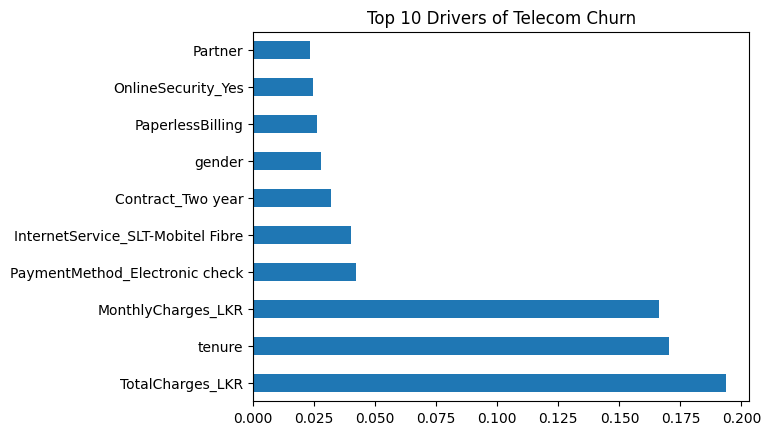

In [61]:
# Feature Importance from Random Forest (Prescriptive Analysis Base)
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Drivers of Telecom Churn')
plt.show()

In [70]:
# Calculate ROC AUC for both models
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print(f"\nROC AUC Scores:\nLogistic Regression: {log_auc:.3f}\nOptimized Random Forest: {rf_auc:.3f}")




ROC AUC Scores:
Logistic Regression: 0.846
Optimized Random Forest: 0.817


---
## Advanced Enhancements: Pipeline Optimization & Interpretability
To elevate this analysis to a production-grade standard, we implement two advanced data science techniques.

### 1. Hyperparameter Tuning via GridSearchCV
Instead of relying on default algorithm settings, we utilize 5-fold cross-validation to systematically search for the mathematically optimal parameters for our Random Forest model. We specifically optimize for the `f1` score and utilize class balancing to handle market data imbalances effectively.

### 2. Prescriptive Strategy via Explainable AI (SHAP)
While ensemble models like Random Forest are highly accurate, they are often considered "black boxes." By implementing SHapley Additive exPlanations (SHAP), we apply game theory to calculate the exact directional impact of each feature on individual predictions. This provides complete transparency, allowing the business to understand exactly *why* the algorithm flagged a user, enabling highly targeted retention campaigns.

01. Hyperparameter Tuning via GridSearchCV

In [71]:
print("Starting Hyperparameter Tuning...")

# 1. Define the parameter grid to explore
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None] # 'balanced' handles Sri Lankan market class imbalances
}

# 2. Initialize the Grid Search with 5-fold Cross-Validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1', # Optimizing for F1-score ensures we balance Precision and Recall
    n_jobs=-1
)

# 3. Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# 4. Extract the best model configuration
best_rf_model = grid_search.best_estimator_
print("\nOptimal Hyperparameters Found:")
print(grid_search.best_params_)

Starting Hyperparameter Tuning...

Optimal Hyperparameters Found:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}


In [72]:
print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, best_rf.predict(X_test)))
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, best_rf.predict(X_test)))


Confusion Matrix (Random Forest):
[[1254  292]
 [ 174  393]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1546
           1       0.57      0.69      0.63       567

    accuracy                           0.78      2113
   macro avg       0.73      0.75      0.74      2113
weighted avg       0.80      0.78      0.79      2113



2. Prescriptive Strategy via Explainable AI (SHAP)

Generating SHAP Global Feature Importance Plot...


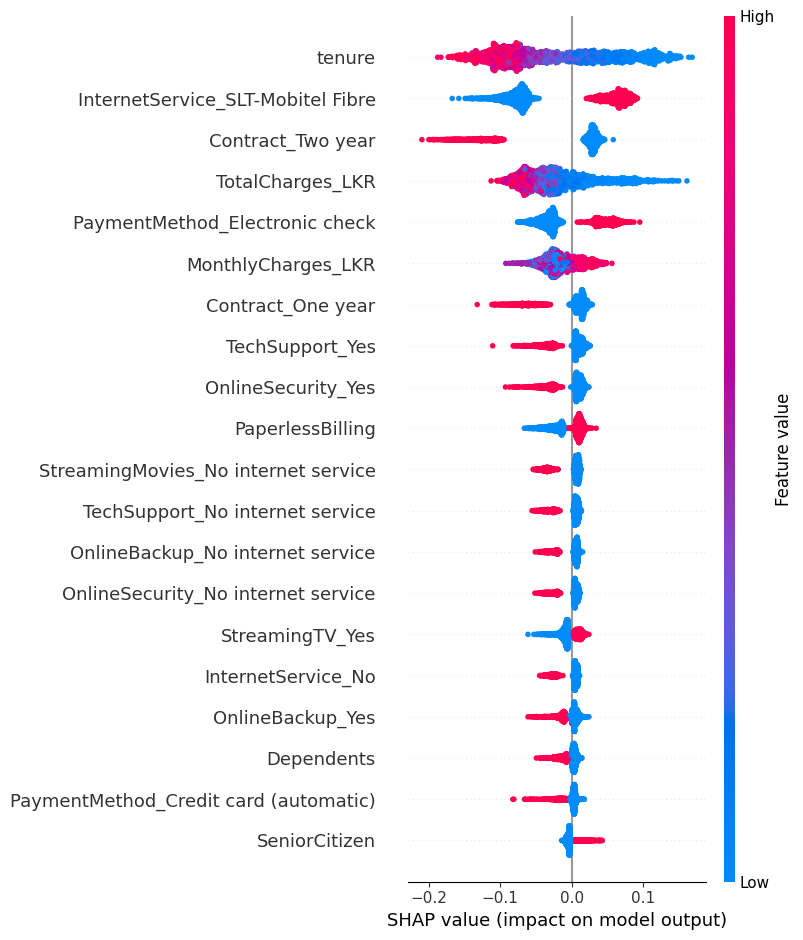

In [73]:
import shap

# 1. Initialize the SHAP explainer with your optimized model
explainer = shap.TreeExplainer(best_rf_model)

# 2. Calculate SHAP values for the test dataset
shap_values = explainer.shap_values(X_test)

# 3. Plot the summary of feature impacts
print("Generating SHAP Global Feature Importance Plot...")
# Note: For binary classification, shap_values[:, :, 1] represents the positive class (Churn)
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X.columns)